In [1]:
%pip install transformers
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Local Inference on GPU
Model page: https://huggingface.co/facebook/sam3

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/facebook/sam3)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

The model you are trying to use is gated. Please make sure you have access to it by visiting the model page.To run inference, either set HF_TOKEN in your environment variables/ Secrets or run the following cell to login. 🤗

In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2.11.0+cu130
CUDA available: True


In [3]:
from huggingface_hub import login
# login()

In [4]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("mask-generation", model="facebook/sam3")

Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

In [5]:
# Load model directly
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("facebook/sam3")
model = AutoModel.from_pretrained("facebook/sam3")

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Using device: cuda


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Original image size: (5300, 2976)
Pass 1 found 1 objects
Pass 1 best score: 0.9570791721343994
Pass 1 best box: [2297, 68, 3691, 1789]
Crop box: [2137, 0, 3851, 1949]
Crop size: (1714, 1949)
Pass 2 found 1 objects
Pass 2 best score: 0.9566730260848999
Pass 2 best box (crop coords): [156, 60, 1579, 1780]
Saved:
content/final_mask.png
content/final_overlay.png
content/refinement_crop.png


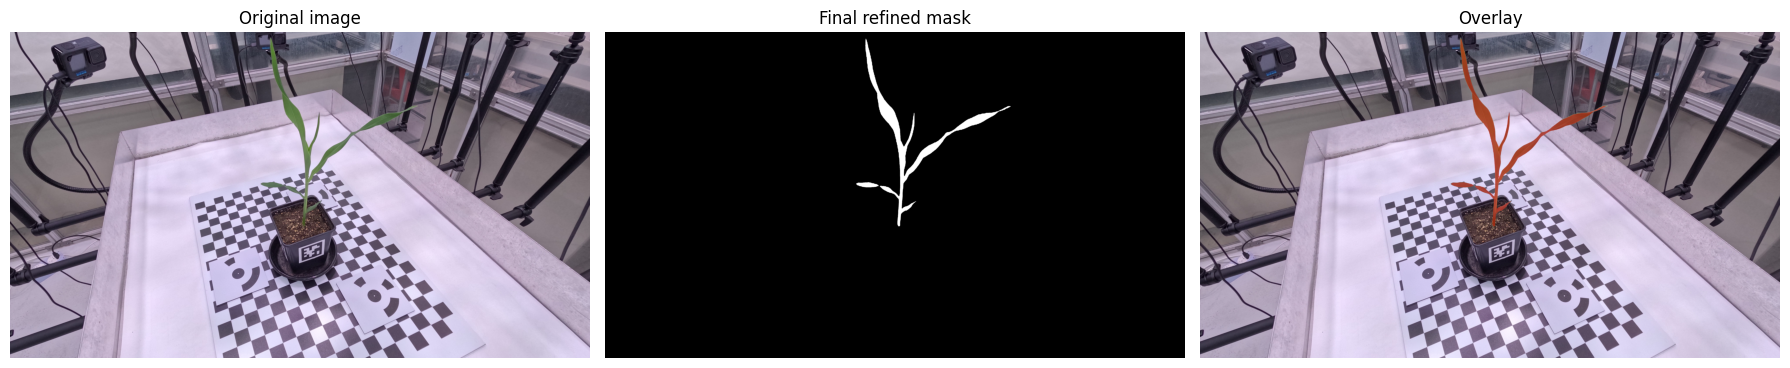

In [15]:
### segment 1 image ###

# !pip install -q transformers torch pillow matplotlib numpy

from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

image_path = "content/GX010009_20250825_070502_1880_0.jpg"
text_prompt = "plant"

# ---------- helpers ----------

def run_sam_text(image, text, threshold=0.5, mask_threshold=0.5):
    inputs = processor(images=image, text=text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs["original_sizes"].tolist()
    )[0]

    return results

def select_best_result(results):
    if len(results["scores"]) == 0:
        return None

    # results["scores"] may already be torch tensor
    if isinstance(results["scores"], torch.Tensor):
        best_idx = int(torch.argmax(results["scores"]).item())
    else:
        best_idx = int(np.argmax(results["scores"]))

    best = {
        "idx": best_idx,
        "score": float(results["scores"][best_idx]),
        "box": results["boxes"][best_idx],
        "mask": results["masks"][best_idx],
    }
    return best

def to_numpy_mask(mask_tensor):
    if isinstance(mask_tensor, torch.Tensor):
        return mask_tensor.detach().cpu().numpy().astype(np.uint8)
    return np.array(mask_tensor).astype(np.uint8)

def to_numpy_box(box_tensor):
    if isinstance(box_tensor, torch.Tensor):
        box = box_tensor.detach().cpu().numpy()
    else:
        box = np.array(box_tensor)
    return box.astype(int)

def expand_box_xyxy(box, image_width, image_height, pad=128):
    x1, y1, x2, y2 = box.tolist()
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(image_width, x2 + pad)
    y2 = min(image_height, y2 + pad)
    return [x1, y1, x2, y2]

def overlay_mask_on_image(image_pil, mask_np, alpha=0.45):
    image_rgba = image_pil.convert("RGBA")
    overlay = Image.new("RGBA", image_pil.size, (255, 0, 0, 0))

    mask_img = Image.fromarray((mask_np > 0).astype(np.uint8) * 255)
    overlay_alpha = mask_img.point(lambda p: int(p * alpha))
    overlay.putalpha(overlay_alpha)

    composed = Image.alpha_composite(image_rgba, overlay)
    return composed

# ---------- load image ----------

image = Image.open(image_path).convert("RGB")
W, H = image.size
print("Original image size:", image.size)

# ---------- pass 1: full image ----------

results_full = run_sam_text(
    image=image,
    text=text_prompt,
    threshold=0.5,
    mask_threshold=0.5
)

print(f"Pass 1 found {len(results_full['masks'])} objects")

best_full = select_best_result(results_full)
if best_full is None:
    raise RuntimeError("No objects found in pass 1.")

full_box = to_numpy_box(best_full["box"])
full_mask = to_numpy_mask(best_full["mask"])

print("Pass 1 best score:", best_full["score"])
print("Pass 1 best box:", full_box.tolist())

# ---------- crop around best detection ----------

crop_box = expand_box_xyxy(full_box, W, H, pad=160)
x1, y1, x2, y2 = crop_box
crop = image.crop((x1, y1, x2, y2))

print("Crop box:", crop_box)
print("Crop size:", crop.size)

# ---------- pass 2: rerun on crop ----------

results_crop = run_sam_text(
    image=crop,
    text=text_prompt,
    threshold=0.5,
    mask_threshold=0.5
)

print(f"Pass 2 found {len(results_crop['masks'])} objects")

best_crop = select_best_result(results_crop)

if best_crop is None:
    print("No objects found in crop pass; falling back to pass 1 mask.")
    refined_mask_full = full_mask
else:
    crop_mask = to_numpy_mask(best_crop["mask"])
    crop_box_inner = to_numpy_box(best_crop["box"])

    print("Pass 2 best score:", best_crop["score"])
    print("Pass 2 best box (crop coords):", crop_box_inner.tolist())

    # paste crop mask back into full-image coordinates
    refined_mask_full = np.zeros((H, W), dtype=np.uint8)
    refined_mask_full[y1:y2, x1:x2] = crop_mask

# ---------- save outputs ----------

mask_png = Image.fromarray((refined_mask_full > 0).astype(np.uint8) * 255)
overlay_png = overlay_mask_on_image(image, refined_mask_full, alpha=0.45)

mask_path = "content/final_mask.png"
overlay_path = "content/final_overlay.png"
crop_path = "content/refinement_crop.png"

mask_png.save(mask_path)
overlay_png.save(overlay_path)
crop.save(crop_path)

print("Saved:")
print(mask_path)
print(overlay_path)
print(crop_path)

# ---------- preview ----------

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(image)
ax1.set_title("Original image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(mask_png, cmap="gray")
ax2.set_title("Final refined mask")
ax2.axis("off")

ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(overlay_png)
ax3.set_title("Overlay")
ax3.axis("off")

plt.tight_layout()
plt.show()


In [6]:
### segment all images in all timestep folders inside one parent folder ###
### skips images that already have a saved mask ###

# !pip install -q transformers torch pillow numpy

from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import numpy as np
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

# ======================
# SETTINGS
# ======================

parent_dir = Path("content/consecutive_timesteps_10")

text_prompt = "plant"
threshold = 0.5
mask_threshold = 0.5
crop_padding = 160

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ======================
# HELPERS
# ======================

def run_sam_text(image):
    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs["original_sizes"].tolist()
    )[0]

    return results


def select_best_result(results):
    if len(results["scores"]) == 0:
        return None

    if isinstance(results["scores"], torch.Tensor):
        idx = int(torch.argmax(results["scores"]).item())
    else:
        idx = int(np.argmax(results["scores"]))

    return {
        "box": results["boxes"][idx],
        "mask": results["masks"][idx],
    }


def to_numpy_mask(mask):
    if isinstance(mask, torch.Tensor):
        return mask.cpu().numpy().astype(np.uint8)
    return np.array(mask).astype(np.uint8)


def to_numpy_box(box):
    if isinstance(box, torch.Tensor):
        return box.cpu().numpy().astype(int)
    return np.array(box).astype(int)


def expand_box(box, W, H, pad):
    x1, y1, x2, y2 = box
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(W, x2 + pad)
    y2 = min(H, y2 + pad)
    return [x1, y1, x2, y2]


# ======================
# PROCESS ONE IMAGE
# ======================

def process_image(image_path, output_dir):
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Failed: {image_path} ({e})")
        return False

    W, H = image.size

    # First pass
    results = run_sam_text(image)
    best = select_best_result(results)

    if best is None:
        print("No detection:", image_path.name)
        return False

    box = to_numpy_box(best["box"])
    mask_full = to_numpy_mask(best["mask"])

    # Crop refinement
    x1, y1, x2, y2 = expand_box(box, W, H, crop_padding)
    crop = image.crop((x1, y1, x2, y2))

    results_crop = run_sam_text(crop)
    best_crop = select_best_result(results_crop)

    if best_crop is None:
        final_mask = mask_full
    else:
        crop_mask = to_numpy_mask(best_crop["mask"])
        final_mask = np.zeros((H, W), dtype=np.uint8)
        final_mask[y1:y2, x1:x2] = crop_mask

    mask_img = Image.fromarray((final_mask > 0).astype(np.uint8) * 255)

    output_path = output_dir / f"{image_path.stem}_mask_sam3.png"
    mask_img.save(output_path)

    print("Saved:", output_path)
    return True


# ======================
# FIND TIMESTEP FOLDERS
# ======================

timestep_dirs = sorted([
    p for p in parent_dir.iterdir()
    if p.is_dir()
])

print(f"Found {len(timestep_dirs)} timestep folders")

# ======================
# RUN ALL FOLDERS
# ======================

total_processed = 0
total_skipped = 0

for timestep_dir in timestep_dirs:
    input_dir = timestep_dir / "images"
    output_dir = timestep_dir / "masks"

    if not input_dir.exists():
        print(f"Skipping {timestep_dir.name}: no images folder")
        continue

    output_dir.mkdir(parents=True, exist_ok=True)

    images = [
        p for p in input_dir.iterdir()
        if p.is_file() and p.suffix.lower() in extensions
    ]

    print(f"\nProcessing folder: {timestep_dir.name}")
    print(f"Input:  {input_dir}")
    print(f"Output: {output_dir}")
    print(f"Found {len(images)} images")

    folder_processed = 0
    folder_skipped = 0

    for img in images:
        output_path = output_dir / f"{img.stem}_mask_sam3.png"

        if output_path.exists():
            print(f"Skipping (already done): {img.name}")
            folder_skipped += 1
            total_skipped += 1
            continue

        success = process_image(img, output_dir)
        if success:
            folder_processed += 1
            total_processed += 1

    print(
        f"Finished {timestep_dir.name}: "
        f"{folder_processed} new, {folder_skipped} skipped"
    )

print(f"\nFinished all folders: {total_processed} new, {total_skipped} skipped.")

Using device: cuda


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Found 11 timestep folders
Skipping .ipynb_checkpoints: no images folder

Processing folder: timestep_2004
Input:  content/consecutive_timesteps_10/timestep_2004/images
Output: content/consecutive_timesteps_10/timestep_2004/masks
Found 22 images
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010094_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010153_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010035_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010083_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010173_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010014_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_timesteps_10/timestep_2004/masks/GX010132_20250912_120302_2006_mask_sam3.png
Saved: content/consecutive_

In [ ]:
### segment movie ###
import torch
import torch.nn.functional as F
from transformers import Sam3VideoModel, Sam3VideoProcessor
from transformers.video_utils import load_video
import numpy as np
from PIL import Image
from pathlib import Path

# ======================
# DEVICE
# ======================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
print("Using device:", device, "| dtype:", dtype)

# ======================
# LOAD MODEL
# ======================

processor = Sam3VideoProcessor.from_pretrained("facebook/sam3")
model = Sam3VideoModel.from_pretrained("facebook/sam3").to(device=device, dtype=dtype)
model.eval()

# ======================
# SETTINGS
# ======================

input_videos_dir = Path("content/videos")
output_masks_dir = Path("content/videos/masks")
output_overlays_dir = Path("content/videos/overlays")

text_prompt = "plant"

video_backend = "opencv"
load_fps = 24                 # big memory saver; try 1 first
resize_max_side = 4000        # big memory saver; try 768 first
max_frame_num_to_track = 10  # now this can help too

output_masks_dir.mkdir(parents=True, exist_ok=True)
output_overlays_dir.mkdir(parents=True, exist_ok=True)

# ======================
# HELPERS
# ======================

def resize_video_frames(video_frames, max_side=768):
    if not torch.is_tensor(video_frames):
        video_frames = torch.as_tensor(video_frames)

    if video_frames.ndim != 4:
        raise ValueError(f"Expected video tensor with shape (T,C,H,W), got {tuple(video_frames.shape)}")

    T, C, H, W = video_frames.shape
    scale = min(max_side / max(H, W), 1.0)
    new_h = int(round(H * scale))
    new_w = int(round(W * scale))

    if scale == 1.0:
        return video_frames

    frames = video_frames.float()
    frames = F.interpolate(frames, size=(new_h, new_w), mode="bilinear", align_corners=False)

    if video_frames.dtype == torch.uint8:
        frames = frames.clamp(0, 255).to(torch.uint8)
    else:
        frames = frames.to(video_frames.dtype)

    return frames


def overlay_mask_on_frame(frame_np, mask_np, color=(0, 255, 0), alpha=0.5):
    frame_np = frame_np.copy()

    if mask_np.dtype != bool:
        mask_np = mask_np > 0

    overlay = frame_np.astype(np.float32)
    color_arr = np.array(color, dtype=np.float32)
    overlay[mask_np] = overlay[mask_np] * (1 - alpha) + color_arr * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)


def tensor_frame_to_numpy_rgb(frame_tensor):
    if not torch.is_tensor(frame_tensor):
        frame_tensor = torch.as_tensor(frame_tensor)

    frame = frame_tensor.detach().cpu()

    if frame.ndim == 3 and frame.shape[0] in (1, 3):
        frame = frame.permute(1, 2, 0)

    frame = frame.numpy()

    if frame.dtype != np.uint8:
        if frame.max() <= 1.0:
            frame = (frame * 255.0).clip(0, 255).astype(np.uint8)
        else:
            frame = frame.clip(0, 255).astype(np.uint8)

    if frame.ndim == 2:
        frame = np.stack([frame] * 3, axis=-1)
    elif frame.ndim == 3 and frame.shape[2] == 1:
        frame = np.repeat(frame, 3, axis=2)

    return frame


def choose_best_mask(processed_outputs):
    if processed_outputs is None:
        return None

    masks = processed_outputs.get("masks", None)
    if masks is None:
        return None

    if not torch.is_tensor(masks):
        masks = torch.as_tensor(masks)

    if masks.numel() == 0:
        return None

    scores = processed_outputs.get("scores", None)
    if scores is not None:
        if not torch.is_tensor(scores):
            scores = torch.as_tensor(scores)
        if scores.numel() > 0:
            best_idx = torch.argmax(scores).item()
            return masks[best_idx].detach().cpu().numpy()

    return masks[0].detach().cpu().numpy()

# ======================
# PROCESS ONE VIDEO
# ======================

def process_video_with_sam3video(video_path: Path):
    print(f"\nProcessing video: {video_path.name}")

    try:
        video_frames, video_metadata = load_video(
            str(video_path),
            backend=video_backend,
            fps=load_fps,
        )
    except Exception as e:
        print(f"Failed to load video {video_path.name}: {e}")
        return

    if video_frames is None or len(video_frames) == 0:
        print(f"Error: No frames loaded from {video_path.name}")
        return

    print("Original loaded shape:", tuple(video_frames.shape))
    video_frames = resize_video_frames(video_frames, max_side=resize_max_side)
    print("Resized shape:", tuple(video_frames.shape))
    print("Metadata:", video_metadata)

    video_name_stem = video_path.stem
    current_video_masks_output_dir = output_masks_dir / video_name_stem
    current_video_overlays_output_dir = output_overlays_dir / video_name_stem
    current_video_masks_output_dir.mkdir(parents=True, exist_ok=True)
    current_video_overlays_output_dir.mkdir(parents=True, exist_ok=True)

    try:
        inference_session = processor.init_video_session(
            video=video_frames,
            inference_device=device,
            processing_device="cpu",
            video_storage_device="cpu",
            dtype=dtype,
        )
    except Exception as e:
        print(f"Failed during init_video_session for {video_path.name}: {e}")
        return

    try:
        inference_session = processor.add_text_prompt(
            inference_session=inference_session,
            text=text_prompt,
        )
    except Exception as e:
        print(f"Failed to add text prompt for {video_path.name}: {e}")
        return

    saved_count = 0

    try:
        with torch.inference_mode():
            for model_outputs in model.propagate_in_video_iterator(
                inference_session=inference_session,
                max_frame_num_to_track=max_frame_num_to_track,
            ):
                frame_idx = int(model_outputs.frame_idx)

                processed_outputs = processor.postprocess_outputs(
                    inference_session,
                    model_outputs,
                )

                best_mask = choose_best_mask(processed_outputs)
                if best_mask is None:
                    print(f"No mask found for frame {frame_idx:05d}")
                    continue

                frame_np = tensor_frame_to_numpy_rgb(video_frames[frame_idx])

                best_mask = np.asarray(best_mask)
                if best_mask.ndim > 2:
                    best_mask = np.squeeze(best_mask)
                best_mask = best_mask > 0

                mask_img = Image.fromarray((best_mask.astype(np.uint8) * 255))
                mask_filename = current_video_masks_output_dir / f"{video_name_stem}_frame_{frame_idx:05d}_mask.png"
                mask_img.save(mask_filename)

                overlay_frame_np = overlay_mask_on_frame(frame_np, best_mask)
                overlay_img = Image.fromarray(overlay_frame_np)
                overlay_filename = current_video_overlays_output_dir / f"{video_name_stem}_frame_{frame_idx:05d}_overlay.jpg"
                overlay_img.save(overlay_filename, quality=85)

                saved_count += 1
                print(f"Saved frame {frame_idx:05d}")

    except Exception as e:
        print(f"Failed during propagation for {video_path.name}: {e}")
        return

    print(f"Finished processing video: {video_path.name}")
    print(f"Saved outputs for {saved_count} frames")

# ======================
# FIND VIDEOS
# ======================

video_extensions = {".mp4", ".avi", ".mov", ".mkv"}

videos = [
    p for p in input_videos_dir.iterdir()
    if p.is_file() and p.suffix.lower() in video_extensions
]

print("Found", len(videos), "video files")

# ======================
# RUN
# ======================

if not videos:
    print(f"No video files found in {input_videos_dir}.")
else:
    for video in videos:
        process_video_with_sam3video(video)

print("\nFinished all video processing.")

Using device: cuda | dtype: torch.bfloat16


Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Found 1 video files

Processing video: GX010014_timelapse.mp4
Original loaded shape: (571, 1488, 2646, 3)
Resized shape: (571, 1488, 2646, 3)
Metadata: VideoMetadata(total_num_frames=571, fps=24.0, width=2646, height=1488, duration=23.791666666666668, video_backend='opencv', frames_indices=array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127,

In [8]:
# zip on google colab

import shutil
from google.colab import files

# Create a zip archive of the 'masks' directory
output_filename = 'masks_archive'
shutil.make_archive(output_filename, 'zip', '/content/consecutive_timesteps_10')

# Provide a download link for the zip file
files.download(output_filename + '.zip')

print(f"All masks from '/content/masks' have been compressed into '{output_filename}.zip' and are ready for download.")

ModuleNotFoundError: No module named 'google.colab'

In [11]:
import shutil
from pathlib import Path

# ======================
# SETTINGS
# ======================

parent_dir = Path("content/consecutive_timesteps_10")

# ======================
# FIND TIMESTEP FOLDERS
# ======================

timestep_dirs = sorted([
    p for p in parent_dir.iterdir()
    if p.is_dir()
])

print(f"Found {len(timestep_dirs)} timestep folders")

# ======================
# CREATE ZIP PER FOLDER
# ======================

for timestep_dir in timestep_dirs:
    images_dir = timestep_dir / "images"
    masks_dir = timestep_dir / "masks"

    if not images_dir.exists() or not masks_dir.exists():
        print(f"Skipping {timestep_dir.name}: missing images/ or masks/")
        continue

    zip_path = parent_dir / f"{timestep_dir.name}_data"

    print(f"\nZipping: {timestep_dir.name}")
    print(f"Output:  {zip_path}.zip")

    # This keeps folder structure: images/ and masks/
    shutil.make_archive(
        base_name=str(zip_path),
        format="zip",
        root_dir=str(timestep_dir),
        base_dir="."   # ensures images/ and masks/ are at top level
    )

print("\nFinished creating all zip files.")

Found 11 timestep folders
Skipping .ipynb_checkpoints: missing images/ or masks/

Zipping: timestep_2004
Output:  content/consecutive_timesteps_10/timestep_2004_data.zip

Zipping: timestep_2016
Output:  content/consecutive_timesteps_10/timestep_2016_data.zip

Zipping: timestep_2028
Output:  content/consecutive_timesteps_10/timestep_2028_data.zip

Zipping: timestep_2040
Output:  content/consecutive_timesteps_10/timestep_2040_data.zip

Zipping: timestep_2052
Output:  content/consecutive_timesteps_10/timestep_2052_data.zip

Zipping: timestep_2064
Output:  content/consecutive_timesteps_10/timestep_2064_data.zip

Zipping: timestep_2076
Output:  content/consecutive_timesteps_10/timestep_2076_data.zip

Zipping: timestep_2088
Output:  content/consecutive_timesteps_10/timestep_2088_data.zip

Zipping: timestep_2100
Output:  content/consecutive_timesteps_10/timestep_2100_data.zip

Zipping: timestep_2112
Output:  content/consecutive_timesteps_10/timestep_2112_data.zip

Finished creating all zip fi

In [31]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import os

# Re-using output_dir and input_dir from previously executed cell (Kw_JLCIM37Bn)
# (Ensure these paths are correct based on your previous processing)
output_dir = Path("/content/masks")
input_dir = Path("/content/images")

# Define output directory for compressed overlays
overlay_output_dir = Path("/content/masks_overlays_compressed")
overlay_output_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving compressed overlays to: {overlay_output_dir}")

def save_overlay_cv2(image_pil, mask_np, out_path):
    """
    Overlays a mask onto an image and saves the compressed result using OpenCV.
    Uses green for the mask color and JPEG quality 50, matching the reference.
    """
    # Convert PIL Image to OpenCV format (RGB to BGR)
    image_rgb = np.array(image_pil)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    overlay = image_bgr.copy()

    # Apply green mask to the overlay where mask_np is True (non-zero)
    # The reference uses green channel for the mask
    overlay[mask_np > 0, 1] = 255  # Set green channel to max for masked pixels

    # Blend original image and overlay with specified alpha values
    blended = cv2.addWeighted(image_bgr, 0.70, overlay, 0.30, 0)

    # Save as heavily compressed JPEG with quality 50
    cv2.imwrite(str(out_path), blended, [cv2.IMWRITE_JPEG_QUALITY, 50])

# Collect image files and their corresponding mask files
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
processed_images = [
    p for p in input_dir.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]
processed_images.sort() # Ensure consistent order

if not processed_images:
    print(f"No images found in: {input_dir}. Skipping overlay generation.")
else:
    for img_file in processed_images:
        # Load original image
        original_image_path = input_dir / img_file.name
        try:
            image_pil = Image.open(original_image_path).convert("RGB")
        except Exception as e:
            print(f"Could not load original image {original_image_path.name}: {e}")
            continue

        # Load corresponding mask (assuming it was saved by the previous step)
        mask_name = f"{img_file.stem}_mask_sam3.png"
        mask_path = output_dir / mask_name

        if not mask_path.exists():
            print(f"Mask not found for {img_file.name} at {mask_path}. Skipping overlay for this image.")
            continue

        try:
            mask_img = Image.open(mask_path).convert("L") # Load mask as grayscale
            mask_np = np.array(mask_img) > 0 # Convert to boolean mask (True for masked pixels)
        except Exception as e:
            print(f"Could not load mask {mask_name}: {e}")
            continue

        # Define output path for the overlay
        overlay_filename = f"{img_file.stem}_overlay_sam3.jpg"
        overlay_out_path = overlay_output_dir / overlay_filename

        # Save the overlay
        save_overlay_cv2(image_pil, mask_np, overlay_out_path)
        print(f"Saved overlay: {overlay_out_path.name}")

    print("Finished generating overlays.")

Saving compressed overlays to: /content/masks_overlays_compressed


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Saved overlay: GX010009_20250818_183002_0001_0_overlay_sam3.jpg
Saved overlay: GX010009_20250825_070502_1880_0_overlay_sam3.jpg
Saved overlay: GX010030_20250818_183002_0001_1_overlay_sam3.jpg
Saved overlay: GX010030_20250825_070502_1880_1_overlay_sam3.jpg
Saved overlay: GX010046_20250818_183002_0001_2_overlay_sam3.jpg
Saved overlay: GX010046_20250825_070502_1880_2_overlay_sam3.jpg
Saved overlay: GX010051_20250818_183002_0001_3_overlay_sam3.jpg
Saved overlay: GX010051_20250825_070502_1880_3_overlay_sam3.jpg
Saved overlay: GX010059_20250818_183002_0001_4_overlay_sam3.jpg
Saved overlay: GX010059_20250825_070502_1880_4_overlay_sam3.jpg
Saved overlay: GX010062_20250818_183002_0001_5_overlay_sam3.jpg
Saved overlay: GX010062_20250825_070502_1880_5_overlay_sam3.jpg
Saved overlay: GX010067_20250818_183002_0001_6_overlay_sam3.jpg
Saved overlay: GX010067_20250825_070502_1880_6_overlay_sam3.jpg
Saved overlay: GX010068_20250818_183002_0001_7_overlay_sam3.jpg
Saved overlay: GX010068_20250825_070502_

In [9]:
import os
import zipfile

# Path to the folder you want to zip
folder_path = "content/maize_4_timestep_2004/masks"
zip_path = "images.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, folder_path)
            zipf.write(file_path, arcname)

print(f"Folder '{folder_path}' has been zipped into '{zip_path}'")

Folder 'content/maize_4_timestep_2004/masks' has been zipped into 'images.zip'
